# Libraries

In [3]:
import pdfplumber
import os
import re
import json
import numpy as np
from sentence_transformers import SentenceTransformer
import torch
from transformers import AutoTokenizer
from sentence_transformers import SentenceTransformer

# Ingest Data 

Process Raw Text: clean, chunk, remove dupplicates

## Extract text from pdf

In [2]:
def extract_text_from_pdf(path):
    with pdfplumber.open(path) as pdf:
        full_text = []
        for page in pdf.pages:
            words = page.extract_words(x_tolerance=3, y_tolerance=3)
            page_text = " ".join([w["text"] for w in words])
            full_text.append(page_text)
        return "\n".join(full_text)


def chunk_text(text, max_words=200):
    words = text.split()
    chunks = []
    for i in range(0, len(words), max_words):
        chunk = " ".join(words[i:i+max_words])
        chunks.append(chunk)
    return chunks

def clean_text_proper(text):
    text = re.sub(r'-\n', '', text)         
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'Copyright.*?\.|Page \d+', '', text, flags=re.IGNORECASE)
    text = re.sub(r'[^\x00-\x7FÀ-ÿ]+', ' ', text)
    return text.strip()

In [4]:
all_chunks = []

for file in os.listdir("data/raw"):
    if file.endswith(".pdf"):
        path = os.path.join("data/raw", file)
        text = extract_text_from_pdf(path)  # ← la nouvelle fonction
        text = clean_text_proper(text)
        words = text.split()
        for i in range(0, len(words), 200):
            chunk = " ".join(words[i:i+200])
            all_chunks.append(chunk)

print(f"Nombre total de chunks : {len(all_chunks)}")
print("Exemple :", all_chunks[0][:300])

os.makedirs("data/processed", exist_ok=True)
with open("data/processed/chunks.json", "w", encoding="utf-8") as f:
    json.dump(all_chunks, f, ensure_ascii=False, indent=2)

print(f"{len(all_chunks)} chunks sauvegardés.")

Nombre total de chunks : 495
Exemple : UBICOMP '14, SEPTEMBER 13 - 17, 2014, SEATTLE, WA, USA InterruptMe: Designing Intelligent Prompting Mechanisms for Pervasive Applications VeljkoPejovic MircoMusolesi SchoolofComputerScience SchoolofComputerScience UniversityofBirmingham,UnitedKingdom UniversityofBirmingham,UnitedKingdom v.pejovic@cs
495 chunks sauvegardés.


## Visualize files content

We identify what to clean:
* Concatenated words: Words are sometimes merged due to PDF formatting (e.g., VeljkoPejovic MircoMusolesi, almostanyonecanbereachedatalltimes) → may slightly affect E5-Large embeddings.

* Headers and metadata: Titles, dates, and keywords (e.g., UBICOMP '14…, AuthorKeywords…) are not main content → can be removed or ignored.

* Page numbers, copyright, ACM citations: (e.g., Copyrightsforcomponents…) → remove to avoid polluting embeddings.

* Special characters and symbols: (–, ©, URLs) → can be removed or replaced with spaces.

* Unnecessary line breaks and split sentences: Many \n and line breaks → should be merged for coherent chunks.

In [5]:
all_chunks = []
for doc in corpus:
    chunks = chunk_text(doc, max_words=200)
    all_chunks.extend(chunks)

print(f"Nombre total de chunks : {len(all_chunks)}")

Nombre total de chunks : 482


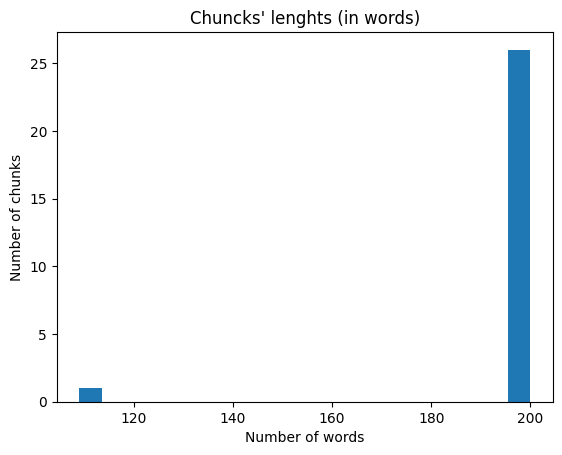

In [6]:
import matplotlib.pyplot as plt

chunk_lengths = [len(chunk.split()) for chunk in chunks_doc0]
plt.hist(chunk_lengths, bins=20)
plt.title("Chuncks' lenghts (in words)")
plt.xlabel("Number of words")
plt.ylabel("Number of chunks")
plt.show()

In [13]:
tokenizer = AutoTokenizer.from_pretrained("intfloat/e5-large") # Automatically detects which tokenizer is best adapter to e5-large
tokenized_chunks = [tokenizer(chunk, truncation=True, padding='max_length', max_length=512) for chunk in all_chunks]

print(f"Tokens du 1er chunk: {tokenized_chunks[0]['input_ids'][:20]}...")
print(f"Nombre de tokens dans le 1er chunk : {len(tokenized_chunks[0]['input_ids'])}")

Tokens du 1er chunk: [101, 1057, 13592, 25377, 1005, 2403, 1010, 2244, 2410, 1011, 2459, 1010, 2297, 1010, 5862, 1010, 11333, 1010, 3915, 17938]...
Nombre de tokens dans le 1er chunk : 512


# Generate embedding

Generate contextual appropriate embedding using E5-Large: continuous value vector

Vector close to eachother => relationship between them

In [8]:
with open("data/processed/chunks.json", "r", encoding="utf-8") as f:
    all_chunks = json.load(f)
print(f"{len(all_chunks)} chunks chargés pour embedding")

# CPU forcé
embedding_model = SentenceTransformer("intfloat/e5-large", device="cpu")
print("Device : cpu")

chunk_embeddings = embedding_model.encode(
    all_chunks,
    batch_size=32,
    normalize_embeddings=True,
    show_progress_bar=True
)

print(f"Dimension d'un embedding : {chunk_embeddings[0].shape}")

np.save("data/processed/chunk_embeddings.npy", chunk_embeddings)
print("Embeddings sauvegardés dans data/processed/chunk_embeddings.npy")

495 chunks chargés pour embedding
Device : cuda


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Dimension d'un embedding : (1024,)
Embeddings sauvegardés dans data/processed/chunk_embeddings.npy


## Visualize 2D

/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


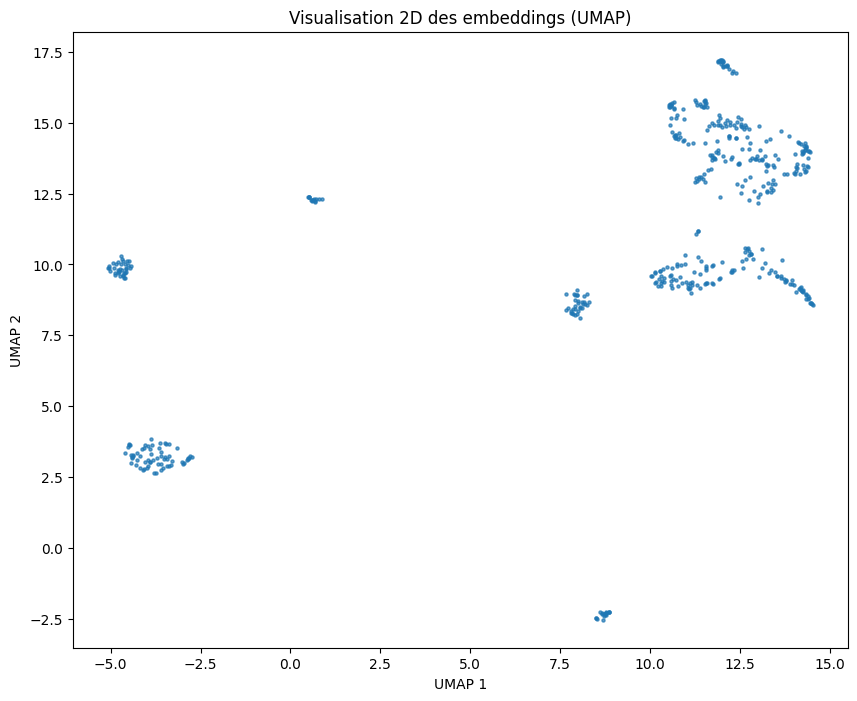

In [20]:
import numpy as np
import umap
import matplotlib.pyplot as plt

embeddings = np.load("data/processed/chunk_embeddings.npy")

reducer = umap.UMAP(n_components=2, random_state=42)
embeddings_2d = reducer.fit_transform(embeddings)

plt.figure(figsize=(10,8))
plt.scatter(embeddings_2d[:,0], embeddings_2d[:,1], s=5, alpha=0.7)
plt.title("Visualisation 2D des embeddings (UMAP)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

# Indexing

## Establish connection and load embeddings

In [4]:
from pymilvus import connections
connections.connect(
    alias="default",
    host="172.17.0.1",  # default Docker bridge gateway
    port=19530
)

In [5]:
embeddings = np.load("data/processed/chunk_embeddings.npy")
with open("data/processed/chunks.json", "r", encoding="utf-8") as f:
    chunks = json.load(f)

print(embeddings.shape)   # (N, 1024)
print(len(chunks))        # N

(495, 1024)
495


## Create a collection

Before creating an index, you need a Milvus collection.
A collection is a table that contains your embeddings.

In [6]:
from pymilvus import FieldSchema, CollectionSchema, DataType, Collection


# ID
id_field = FieldSchema(
    name="id", 
    dtype=DataType.INT64,
    is_primary=True,
)

# Vector embedding
embedding_field = FieldSchema(
    name="embedding", 
    dtype=DataType.FLOAT_VECTOR,
    dim=1024
)

# Texte
text_field = FieldSchema(
    name='text',
    dtype=DataType.VARCHAR,
    max_length=16384
)

# Construct schema
schema = CollectionSchema(
    fields=[id_field, embedding_field, text_field],
    description="Collection for embeddings"
)

# Create collection
collection = Collection(
    name='documents',
    schema=schema, 
    using="default"
)

collection.insert([
    list(range(len(chunks))),
    embeddings.tolist(),
    chunks
])

collection.flush()

collection.create_index(
    field_name="embedding",
    index_params={
        "metric_type": "IP",
        "index_type": "IVF_FLAT",
        "params": {"nlist": 128}
    }
)

print("Indexing done.")

Indexing done.


In [7]:
from pymilvus import Collection

# Si tu es déjà connecté, pas besoin de reconnect
collection = Collection("documents")
print("Nombre de documents:", collection.num_entities)

for field in collection.schema.fields:
    print(f"Champ: {field.name}, Type: {field.dtype}, Params: {field.params}")

Nombre de documents: 3465
Champ: id, Type: 5, Params: {}
Champ: embedding, Type: 101, Params: {'dim': 1024}
Champ: text, Type: 21, Params: {'max_length': 16384}


In [8]:
results = collection.query(
    expr="id >= 0",
    output_fields=["id", "text"],
    limit=10
)
for r in results:
    print(f"ID {r['id']}: {r['text'][:150]}")
    print("---")

ID 0: UBICOMP '14, SEPTEMBER 13 - 17, 2014, SEATTLE, WA, USA InterruptMe: Designing Intelligent Prompting Mechanisms for Pervasive Applications VeljkoPejovi
---
ID 1: Android smartphones. An extensive exper- recommendation to health and behavior tracking, from per- iment shows that, compared to a context-unaware app
---
ID 2: an interruption mechanism for mobile devices Inter- Permissiontomakedigitalorhardcopiesofallorpartofthisworkforpersonalor ruptMe, alibraryforintellige
---
ID 3: s wider context is taken into account. otheropportunitiescanbeuncoverediffullmobilesensingis Thus,Horwitzetal. useanexternalcameraandmicrophone employ
---
ID 4: Nevertheless, tunemomentswemaximizethesuccessofdeliveringcontent. BusyBody proved valuable for refining the machine learn- First,however,wemustdefinew
---
ID 5: 2 3 4 5 6 7 8 9 1011121314151617181920 interval. Thisflavorofresponsivenessisrelevantinthecase of an interruption that reminds a user to take a medica
---
ID 6: [18, 19, 13, 12, 37], differ

In [9]:
collection.load()
from sentence_transformers import SentenceTransformer

query_model = SentenceTransformer("intfloat/e5-large")  
query_text = "user's attention"
query_embedding = query_model.encode([query_text], normalize_embeddings=True).tolist()

results = collection.search(
    data=query_embedding,
    anns_field="embedding",
    param={"metric_type": "IP", "params": {"nprobe": 10}},
    limit=5,
    output_fields=["text"]
)

for hits in results:
    for hit in hits:
        print(f"Score: {hit.score:.4f}")
        print(f"Texte: {hit.entity.get('text')[:300]}")
        print("---")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.10/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU1 NVIDIA GeForce GTX 1080 which is of cuda capability 6.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/usr/local/lib/python3.10/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/usr/local/lib/python3.10/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
NVIDIA GeForce GTX 1080 with CUDA capability sm_61 is not compatible with the current PyTorch insta

Score: 0.8516
Texte: thereminderandwilltake appropriateaction. Foruserresponserate,thismetricrepresentstherateatwhichusers respondtothenotificationstheyreceive. Itmeasuresthelevelofuserengagementand interactionwiththenotifications. Ahigherresponserateimpliesthattheusersaremore actively involved and attentive to the noti
---
Score: 0.8483
Texte: goals our experimental approachyieldsthefollowingcontribution,anoverviewofwhichisdepictedin Figure1.1: (a)QuantificationandAssessmentofUsers Attentiveness Inafieldstudy,wecollectedgroundtruthforquantifyingpeople sattentiveness and receptiveness to interruptions. By applying a machine learning model 
---
Score: 0.8427
Texte: contentsuggestionstudiesdescribedinChapter6. Theengagementstudiesweconducted,showhowattentionalstatesarelinked to people s mobile device activities. In the next step, we focused the user s situationalcontexttosupportinformationintake. Chapter4consideredcontextin theformofcontent-awareness: thisinves
---
Score: 0.8413
Texte: w